A. Import Library

In [1]:
import pandas as  pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

B. Dataset

In [2]:
df = pd.read_csv('../data/fmcg_sales_marketing_profitability_2023_2025.csv')
df.head()

,Order_ID,Order_Date,Year,Quarter,Month,Month_Name,Region,Country,City,Sales_Person,...,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
0,FMCG-2025-000001,2025-09-26,2025,Q3,9,September,Oceania,Australia,Perth,Ethan Cole,...,73,8.47,8.94,618.31,66.05,314.09,43.03,563.03,139.86,24.84
1,FMCG-2024-000002,2024-10-09,2024,Q4,10,October,Asia,India,Mumbai,Meera Nair,...,99,2.89,9.86,286.11,35.26,123.79,23.89,257.90,74.96,29.07
2,FMCG-2024-000003,2024-07-06,2024,Q3,7,July,North America,USA,Los Angeles,Nina Booker,...,361,5.96,15.32,2151.56,171.46,1011.60,107.02,1821.94,531.86,29.19
3,FMCG-2024-000004,2024-05-25,2024,Q2,5,May,Europe,France,Paris,Oliver Kent,...,603,3.80,18.00,2291.40,118.39,1133.66,85.20,1878.95,541.70,28.83
4,FMCG-2023-000005,2023-08-10,2023,Q3,8,August,Europe,France,Lyon,Lucas Bennett,...,113,3.18,12.46,359.34,34.82,157.70,23.02,314.57,99.03,31.48


C. Preliminary Data Inspection (Understanding Data Characteristic)

In [3]:
print('Dataset Info: ')
df.info(verbose=True, show_counts=True)

display(df.describe())
print(f"\nDataset structure: {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18240 entries, 0 to 18239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_ID             18240 non-null  object 
 1   Order_Date           18240 non-null  object 
 2   Year                 18240 non-null  int64  
 3   Quarter              18240 non-null  object 
 4   Month                18240 non-null  int64  
 5   Month_Name           18240 non-null  object 
 6   Region               18240 non-null  object 
 7   Country              18240 non-null  object 
 8   City                 18240 non-null  object 
 9   Sales_Person         18240 non-null  object 
 10  Customer_Type        18240 non-null  object 
 11  Sales_Channel        18240 non-null  object 
 12  Promotion_Type       18240 non-null  object 
 13  Product_Category     18240 non-null  object 
 14  Brand                18240 non-null  object 
 15  Product_Name         

,Year,Month,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
count,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000
mean,2024.001590,6.519024,212.909759,4.467254,12.935771,936.431746,85.741888,471.024278,54.031789,792.210526,181.412572,19.870780
std,0.816752,3.467308,202.102318,1.949341,5.735972,1045.606955,87.551045,537.351019,51.266996,861.237271,239.526879,10.569275
min,2023.000000,1.000000,5.000000,1.450000,0.000000,13.020000,1.810000,6.310000,1.080000,10.540000,-637.500000,-45.310000
25%,2023.000000,3.000000,70.000000,3.020000,8.710000,274.532500,33.495000,140.510000,21.370000,245.217500,32.345000,13.720000
50%,2024.000000,7.000000,139.000000,3.990000,12.690000,565.430000,61.385000,287.165000,38.985000,493.895000,91.890000,20.870000
75%,2025.000000,10.000000,288.000000,5.440000,16.850000,1213.835000,107.605000,599.790000,69.240000,1027.362500,239.117500,27.260000
max,2025.000000,12.000000,1366.000000,12.740000,28.000000,10634.120000,1767.710000,6473.330000,628.860000,8752.940000,2723.000000,44.490000



Dataset structure: 18240 rows and 27 columns.


D. Data Cleaning

1. Check for duplicated data and missing values

In [4]:
# Check for duplicated data
num_duplicate = df.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicate}")

if num_duplicate > 0:
  df = df.drop_duplicates()
  print("Duplicated data has been remove")

# Check for missing value
print(f"\nMissing Values per Column: ")
print(df.isnull().sum())

Number of duplicated rows: 0

Missing Values per Column: 
Order_ID               0
Order_Date             0
Year                   0
Quarter                0
Month                  0
Month_Name             0
Region                 0
Country                0
City                   0
Sales_Person           0
Customer_Type          0
Sales_Channel          0
Promotion_Type         0
Product_Category       0
Brand                  0
Product_Name           0
SKU                    0
Units_Sold             0
Unit_Price_USD         0
Discount_Pct           0
Gross_Sales_USD        0
Marketing_Spend_USD    0
COGS_USD               0
Logistics_Cost_USD     0
Net_Revenue_USD        0
Profit_USD             0
Profit_Margin_Pct      0
dtype: int64


2. Fix data types

In [5]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Quarter'] = df['Quarter'].astype('category')
df['Customer_Type'] = df['Customer_Type'].astype('category')
df['Region'] = df['Region'].astype('category')
df['Sales_Channel'] = df['Sales_Channel'].astype('category')

df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18240 entries, 0 to 18239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order_ID             18240 non-null  object        
 1   Order_Date           18240 non-null  datetime64[ns]
 2   Year                 18240 non-null  int64         
 3   Quarter              18240 non-null  category      
 4   Month                18240 non-null  int64         
 5   Month_Name           18240 non-null  object        
 6   Region               18240 non-null  category      
 7   Country              18240 non-null  object        
 8   City                 18240 non-null  object        
 9   Sales_Person         18240 non-null  object        
 10  Customer_Type        18240 non-null  category      
 11  Sales_Channel        18240 non-null  category      
 12  Promotion_Type       18240 non-null  object        
 13  Product_Category     18240 non-

3. Check for anomaly/outlier

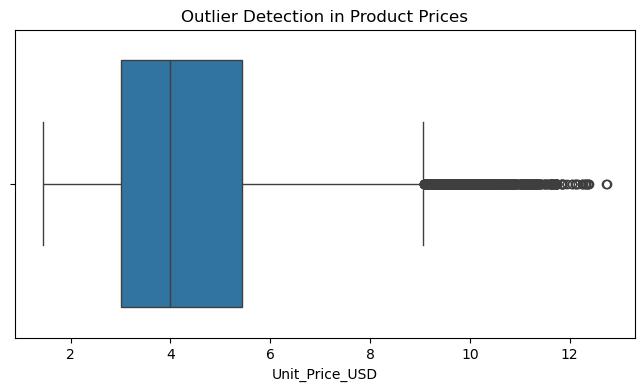

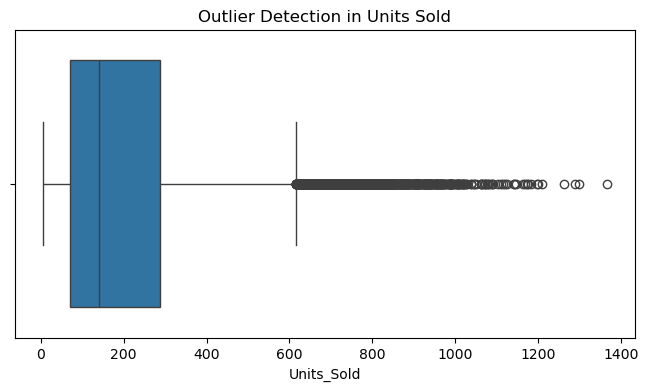

In [6]:
# Create a boxplot to visualize the distribution of product prices
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Unit_Price_USD'])
plt.title('Outlier Detection in Product Prices')
plt.show()

# Create a boxplot to visualize the distribution of units sold
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Units_Sold'])
plt.title('Outlier Detection in Units Sold')
plt.show()

E. Feature Engeneering

In [ ]:
# Profitability Status Features
df['Profit_Status'] = np.where(
    df['Profit_USD'] < 0, 'Loss',
    np.where(df['Profit_USD'] > 0, 'Gain', 'Break Even')
)

df['Profit_Status'].value_counts()

Profit_Status
Gain          17454
Loss            784
Break Even        2
Name: count, dtype: int64

In [17]:
# Time-Based Features
# 1. Generating a day-of-week column
df['Days_of_Week'] = df['Order_Date'].dt.day_name()

# 2. Generating a weekend vs. weekday flag column
df['Is_Weekend'] = df['Order_Date'].dt.dayofweek >= 5
df['Is_Weekend'] = df['Is_Weekend'].replace({True: 'Weekend', False: 'Weekday'})

df['Is_Weekend'].value_counts()

Is_Weekend
Weekday    12988
Weekend     5252
Name: count, dtype: int64

In [18]:
# Define bin thresholds for order size categories
# Example: 0–100 units (Retail), 101–500 units (Medium), above 500 units (Wholesale)
bins = [0, 100, 500, float('inf')]

# Define category labels
labels = ['Retail', 'Medium', 'Wholesale']

# Apply binning to create a new categorical column
df['Order_Size_Category'] = pd.cut(df['Units_Sold'], bins=bins, labels=labels)

df['Order_Size_Category'].value_counts()

Order_Size_Category
Medium       9242
Retail       7007
Wholesale    1991
Name: count, dtype: int64

In [ ]:
# Define logical conditions
conditions = [
    # 1: Discount applied, but results in a loss (Profit < 0)
    (df['Discount_Pct'] > 0) & (df['Profit_USD'] < 0),
    
    # 2: Discount applied, and still profitable (Profit > 0)
    (df['Discount_Pct'] > 0) & (df['Profit_USD'] > 0),
    
    # 3: No discount applied
    (df['Discount_Pct'] == 0)
]

# Define corresponding labels for each condition
labels = ['Unprofitable Discount', 'Profitable Discount', 'No Discount']

# Apply conditions to create a new categorical column
# Any values outside the defined conditions will be labeled as 'Other'
df['Discount_Impact'] = np.select(conditions, labels, default='Other')

df['Discount_Impact'].value_counts()

Discount_Impact
Profitable Discount      17454
Unprofitable Discount      783
Other                        2
No Discount                  1
Name: count, dtype: int64